# Overview of Intermediate Goal: Signal Analysis 

This notebook intends to use a Short-Time Fourier Transform (STFT) and Wavelet Transform (WT) to extract frequency-domained features. Many common audio features rely on the frequency spectrum, which is obtained through STFT. A study entitled "Voice-Based Early Diagnosis of Parkinson’s Disease Using Spectrogram Features and AI Models" by Quamar et al. (2025) uses features such as Spectral Centroid, Spectral Bandwidth, Spectral Contrast, and Mel-Frequency Ceptral Coefficients (MFCCs) to detect Parkinson's Disease. 

A WT will also be used to extract time-frequency statistics such as mean coefficient, variance, and energy per scale to help capture irregular tremors.

For the FFT, the Librosa python library will be used as it converts time-domain audio signals into frequency-domain representations (spectrograms). It uses FFT as backends for frequency calculations. Further, PyWavelets will also be used for wavelet transforms as it is commonly used for time-frequency decomposition. 

By the end of this section, an EDA will be performed to show differences between a healthy person's voice and a PD candidate's voice. 

Brief Definitions of Features: 
1) Spectral Centoid - brightness of sound 
2) Spectral Bandwidth - spread of frequencies 
3) Spectral Contrast - harmonic vs noise differences 
4) MFCCs - vocal tract characteristics
5) Mean Coefficient of WT - average signal strength 
6) Variance of Coefficients of WT - how much the signal fluctuates (tremor) 
7) Energy per scale of WT - total power of the signal of that frequency scale 



In [23]:
%pip install librosa
%pip install PyWavelets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [68]:
# setting up the notebook 

import librosa 
import librosa.display 
import pywt
import pandas as pd 
import seaborn as sns 
import numpy as np

import os 
from glob import glob
from tqdm import tqdm

In [26]:
'''Code for Feature Extraction'''

# Setting targets for the audio files
data_map = {
    "Parkinson's Dataset/HC_AH/HC_AH/*.wav": 0,    # Healthy Control
    "Parkinson's Dataset/PD_AH/PD_AH/*.wav": 1     # Parkinson's Disease
}

features_list = []

for path_pattern, target in data_map.items():
    audio_files = glob(path_pattern)
    print(f"Processing {len(audio_files)} files for target: {target}")

    # Setting up a progress bar
    for file in tqdm(audio_files, desc=f"Target {target}", unit="file"):
        
        x, sr = librosa.load(file, sr=None)
        stft = np.abs(librosa.stft(x))

        # Feature Extraction
        mfcc1 = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc1, axis=1)

        spectral_centroid = librosa.feature.spectral_centroid(y=x, sr=sr)
        centroid_mean = np.mean(spectral_centroid)

        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=x, sr=sr)
        bandwidth_mean = np.mean(spectral_bandwidth)

        spectral_contrast = librosa.feature.spectral_contrast(S=stft, sr=sr, n_bands=3)
        contrast_mean = np.mean(spectral_contrast, axis=1)

        # Combine features + label
        feature_row = np.hstack([
            mfcc_mean,
            centroid_mean,
            bandwidth_mean,
            contrast_mean,
            target
        ])

        # Append everything 
        features_list.append(feature_row)

# Column Labels
mfcc_names = [f"mfcc_{i}" for i in range(1, 14)]
spectral_names = ["spectral_centroid", "spectral_bandwidth"]
contrast_names = [f"contrast_band_{i}" for i in range(1, 5)]
column_labels = mfcc_names + spectral_names + contrast_names + ["target"]

# Create DataFrame
df = pd.DataFrame(features_list, columns=column_labels)

print("Extraction Complete. Dataframe Shape:", df.shape)
df

Processing 41 files for target: 0


Target 0: 100%|█████████████████████████████████████████████████████████████████████| 41/41 [00:00<00:00, 107.44file/s]


Processing 40 files for target: 1


Target 1: 100%|█████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 104.21file/s]

Extraction Complete. Dataframe Shape: (81, 20)


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,spectral_bandwidth,contrast_band_1,contrast_band_2,contrast_band_3,contrast_band_4,target
0,-34.671783,46.427185,-63.750423,-37.945095,-5.174286,-7.978308,-11.592722,7.337579,9.517365,-9.009621,-21.090189,-7.455282,-6.077338,1104.893589,741.075744,24.806168,27.109300,29.031058,29.002101,0.0
1,-51.353390,88.080132,-59.384941,-22.281412,-16.072655,-1.175686,-12.314146,-1.524578,0.616782,-12.499595,-9.319973,-13.819527,-2.889428,932.762445,658.452860,26.253622,25.037222,22.921611,27.640020,0.0
2,-75.293953,69.476532,-39.382324,-20.257771,-0.351907,0.462403,-16.158535,-2.635781,-15.651364,-16.545940,-8.706078,-8.037354,-8.123940,921.438546,725.465544,15.140855,30.398796,27.958255,29.106558,0.0
3,-32.810532,64.750412,-44.563965,-25.503115,-10.679801,0.391478,-19.562962,4.752218,0.198751,-25.886776,-19.472654,-13.636947,-1.386326,1023.948012,788.648102,27.203380,27.528240,27.385805,27.324650,0.0
4,-69.802628,41.698448,-55.650742,-45.029232,2.411105,8.187595,-28.289539,14.828458,-2.618405,-4.690909,-24.383987,-14.418140,7.071354,1229.625748,821.848030,22.416047,24.273961,26.204595,27.436695,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,-175.285690,38.995998,-36.874859,-34.680492,22.312656,-9.648567,-16.332352,5.128305,-9.038811,4.585876,-15.523121,3.245329,-15.609770,1349.832602,974.581309,23.384316,24.872782,25.014791,26.969288,1.0
77,-182.891846,55.136276,-31.717503,-49.519794,0.165608,11.415182,-20.467979,7.393897,1.737478,-1.373219,-22.136343,-15.020916,3.766758,1118.477422,826.369012,26.053243,25.043910,28.198584,28.063913,1.0
78,-64.881943,-20.999617,-51.011646,20.657621,-10.907411,-4.179439,15.597313,-22.053579,-18.473082,22.235464,-17.968420,-8.981183,-8.029469,1580.412201,718.134821,13.688773,28.211730,27.847201,30.238863,1.0
79,-80.320450,83.589615,-23.517599,-19.847649,-7.128909,-2.610546,-28.880053,-3.599473,10.541465,-11.141140,-20.561964,-25.042875,-2.383995,908.430621,783.307474,25.792100,25.800800,23.652257,25.577980,1.0


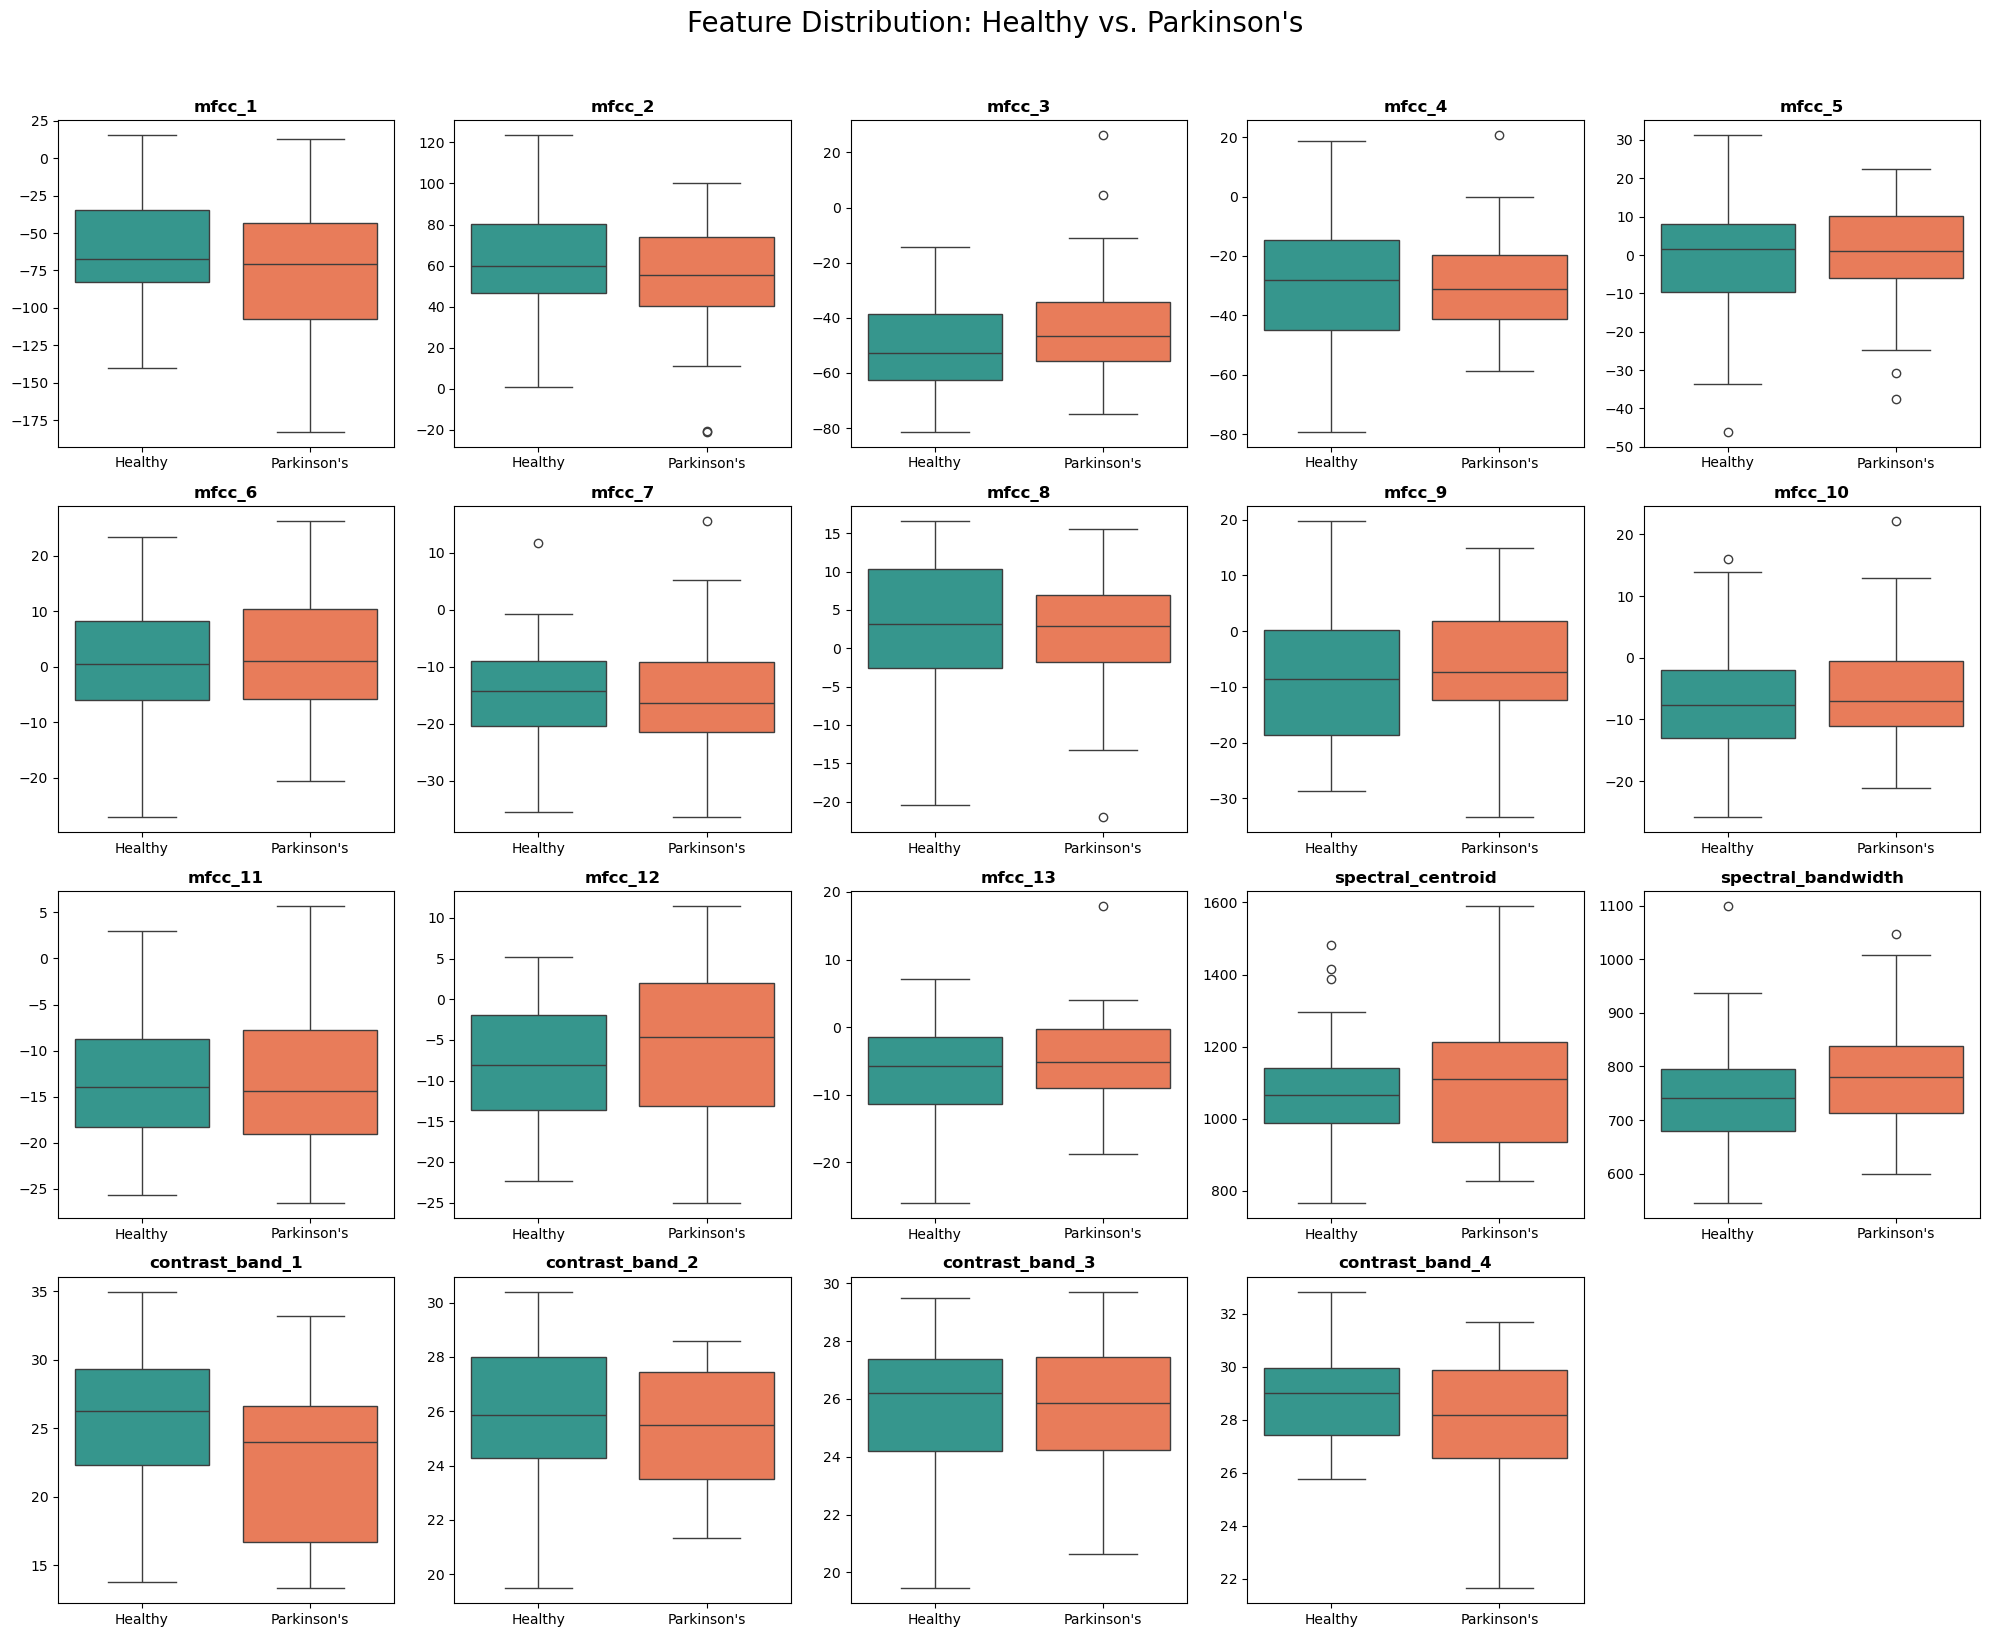

In [42]:
'''Code for EDA'''

# Convert labels for the legend/axis
df["target_label"] = df["target"].map({0: "Healthy", 1: "Parkinson's"})

# Get all features except the target 
feature_cols = [col for col in df.columns if col not in ['target', 'target_label']]

plt.figure(figsize=(20, 16))

# Define a color palette 
palette = { "Healthy": "#26a69a", "Parkinson's": "#ff7043" }

# Set up the graph format 
for i, feature in enumerate(feature_cols):
    plt.subplot(4, 5, i + 1)

    # plot 
    
    sns.boxplot(
        x="target_label", 
        y=feature, 
        data=df,
        palette=palette,
        hue="target_label", 
        legend=False
    )
    
    plt.title(feature, fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Feature Distribution: Healthy vs. Parkinson's", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()